# 01 — EDA e Modelos Baseline para Previsão de Churn em Telecomunicações

---

## 1. Introdução

### Problema de Negócio

Uma operadora de telecomunicações está enfrentando uma taxa acelerada de perda de clientes (*churn*). A capacidade de prever quais clientes têm maior probabilidade de cancelar seus contratos é estrategicamente crítica, pois o custo de aquisição de novos clientes é, em média, **5 a 7 vezes maior** do que o custo de retenção de clientes existentes.

A diretoria demanda um modelo preditivo que permita à equipe de Customer Success e ao time de retenção identificar clientes em risco com antecedência suficiente para executar ações preventivas personalizadas.

### Objetivo

Neste notebook, realizamos:
1. **Análise Exploratória de Dados (EDA)** completa do dataset Telco Customer Churn.
2. **Avaliação de Prontidão dos Dados** (*Data Readiness Assessment*).
3. Treinamento e avaliação de **modelos baseline** rastreados com **MLflow**.

Os resultados desta fase estabelecem a linha de base (*baseline*) de desempenho para as iterações futuras do projeto.

### Variável Alvo

- **`Churn`**: Variável binária que indica se o cliente cancelou o serviço no último mês (`Yes`) ou permaneceu ativo (`No`).
- Para modelagem, será transformada em `1` (Churn) e `0` (Não Churn).

---

## 2. ML Canvas

O ML Canvas é um artefato de alinhamento entre a solução técnica e os objetivos de negócio. Ele garante que todas as partes interessadas compartilhem a mesma visão sobre o que será construído e como o sucesso será medido.

| Dimensão | Descrição |
|---|---|
| **Stakeholders** | Diretoria, Marketing, Customer Success, Equipe de Retenção |
| **Decisão de Negócio** | Identificar clientes com alta probabilidade de churn nos próximos 30 dias |
| **Ação** | Acionar campanhas personalizadas de retenção (descontos, upgrades, contato proativo) |
| **Métrica de Negócio** | Redução do custo total de churn; aumento da taxa de retenção (%) |
| **Métricas Técnicas** | ROC-AUC, PR-AUC, F1-Score, Recall |
| **SLOs Propostos** | Recall ≥ 75% · ROC-AUC ≥ 0.80 · Latência de inferência ≤ 200 ms |
| **Dados Disponíveis** | Dataset histórico com ~7k clientes e 20 features de uso, contrato e perfil |
| **Riscos** | Desbalanceamento de classes (~26% churn) · Possível data drift em produção |
| **Frequência de Predição** | Batch diário ou on-demand via API REST |


---

## 3. Carregamento dos Dados

In [1]:
import warnings
import os
import sys
import datetime
import hashlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay,
)

import mlflow
import mlflow.sklearn

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 100, 'figure.facecolor': 'white'})

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(f'Python  : {sys.version.split()[0]}')
print(f'Pandas  : {pd.__version__}')
print(f'MLflow  : {mlflow.__version__}')

Python  : 3.14.5
Pandas  : 2.3.3
MLflow  : 3.13.0


In [2]:
DATA_PATH = os.path.join('..', 'dataset', 'Dataset Telco-Customer-Churn.csv')

df_raw = pd.read_csv(DATA_PATH)

print(f'Shape: {df_raw.shape[0]:,} linhas x {df_raw.shape[1]} colunas')
print('\nTipos das colunas:')
print(df_raw.dtypes)
print('\nAmostra (5 primeiras linhas):')
df_raw.head()

Shape: 7,043 linhas x 21 colunas

Tipos das colunas:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Amostra (5 primeiras linhas):


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


---

## 4. Data Readiness Assessment

Antes de modelar, avaliamos a **qualidade, volume e integridade** dos dados. Esta etapa é fundamental para identificar problemas que possam comprometer os resultados dos modelos.

In [3]:
n_rows, n_cols = df_raw.shape
print('=' * 45)
print('  DATA READINESS ASSESSMENT')
print('=' * 45)
print('\n[VOLUME]')
print(f'  Linhas   : {n_rows:,}')
print(f'  Colunas  : {n_cols}')

n_dup = df_raw.duplicated().sum()
print('\n[DUPLICADOS]')
print(f'  Linhas duplicadas: {n_dup}')

print('\n[MISSING VALUES]')
missing = df_raw.isnull().sum()
missing_pct = (missing / n_rows * 100).round(2)
missing_df = pd.DataFrame({'Ausentes': missing, 'Percentual (%)': missing_pct})
missing_df = missing_df[missing_df['Ausentes'] > 0]
if missing_df.empty:
    print('  Nenhum valor ausente detectado (NaN padrao).')
else:
    print(missing_df)

print('\n[INTEGRIDADE]')
tc_problematic = pd.to_numeric(df_raw['TotalCharges'], errors='coerce').isna().sum()
print(f'  TotalCharges com valores nao-numericos: {tc_problematic}')
print(f'  Tipo atual de TotalCharges            : {df_raw["TotalCharges"].dtype}')

  DATA READINESS ASSESSMENT

[VOLUME]
  Linhas   : 7,043
  Colunas  : 21

[DUPLICADOS]
  Linhas duplicadas: 0

[MISSING VALUES]
  Nenhum valor ausente detectado (NaN padrao).

[INTEGRIDADE]
  TotalCharges com valores nao-numericos: 11
  Tipo atual de TotalCharges            : object


In [4]:
dtype_summary = pd.DataFrame({
    'Coluna': df_raw.columns,
    'Dtype': df_raw.dtypes.values,
    'Unicos': df_raw.nunique().values,
    'Missing': df_raw.isnull().sum().values,
    'Missing %': (df_raw.isnull().sum().values / n_rows * 100).round(2),
    'Exemplo': [
        df_raw[c].dropna().iloc[0] if not df_raw[c].dropna().empty else None
        for c in df_raw.columns
    ],
})
dtype_summary

,Coluna,Dtype,Unicos,Missing,Missing %,Exemplo
0,customerID,object,7043,0,0.0,7590-VHVEG
1,gender,object,2,0,0.0,Female
2,SeniorCitizen,int64,2,0,0.0,0
3,Partner,object,2,0,0.0,Yes
4,Dependents,object,2,0,0.0,No
5,tenure,int64,73,0,0.0,1
6,PhoneService,object,2,0,0.0,No
7,MultipleLines,object,3,0,0.0,No phone service
8,InternetService,object,3,0,0.0,DSL
9,OnlineSecurity,object,3,0,0.0,No


In [ ]:
# TotalCharges esta como object por conter espacos em clientes com tenure=0.
# Convertido para float e imputado a mediana nos registros invalidos.
df = df_raw.copy()
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

median_tc = df['TotalCharges'].median()
n_fixed = df['TotalCharges'].isna().sum()
df['TotalCharges'] = df['TotalCharges'].fillna(median_tc)

print(f'TotalCharges: {n_fixed} valor(es) invalido(s) substituido(s) pela mediana ({median_tc:.2f}).')
print(f'Novo dtype: {df["TotalCharges"].dtype}')

TotalCharges: 11 valor(es) invalido(s) substituido(s) pela mediana (1397.47).
Novo dtype: float64


**Decisoes tomadas:**
- `customerID` e um identificador unico sem valor preditivo — sera removido antes da modelagem.
- `TotalCharges` foi carregado como `object` porque registros com `tenure=0` contem espacos em branco. Convertidos para `float64` e imputado a mediana nos casos invalidos.
- Nao ha duplicatas nem missings estruturais no dataset.

---

## 5. Analise Exploratoria de Dados (EDA)

A EDA nos permite compreender a distribuicao das variaveis, identificar padroes e formular hipoteses sobre os drivers de churn.

### 5.1 Analise da Variavel Alvo

Antes de qualquer analise bivariada, e fundamental entender a distribuicao da variavel-alvo. O **desbalanceamento** entre classes afeta diretamente a escolha da metrica de avaliacao e as estrategias de modelagem.

Distribuicao da variavel Churn:
       Contagem  Percentual (%)
Churn                          
No         5174           73.46
Yes        1869           26.54


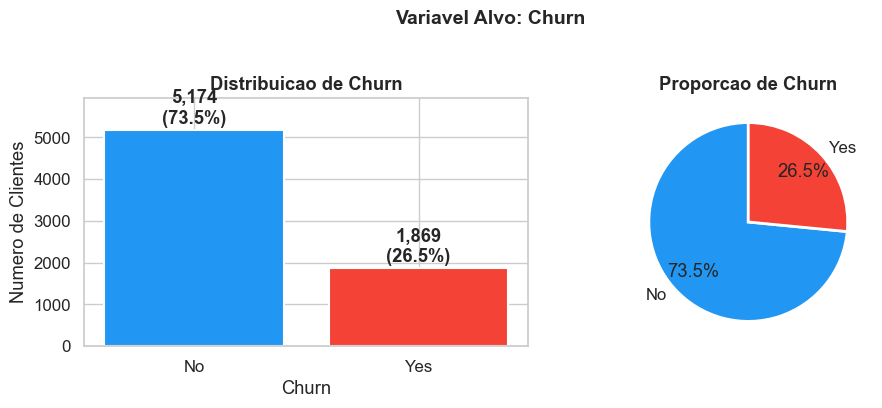


>> Razao de desbalanceamento (No:Yes) = 2.8:1
>> Dataset moderadamente desbalanceado — estratificacao no split e obrigatoria.


In [6]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print('Distribuicao da variavel Churn:')
print(pd.DataFrame({'Contagem': churn_counts, 'Percentual (%)': churn_pct.round(2)}))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
colors = ['#2196F3', '#F44336']

axes[0].bar(churn_counts.index, churn_counts.values, color=colors, edgecolor='white', linewidth=1.5)
for i, (label, count) in enumerate(zip(churn_counts.index, churn_counts.values)):
    axes[0].text(i, count + 50, f'{count:,}\n({churn_pct[label]:.1f}%)',
                 ha='center', va='bottom', fontweight='bold')
axes[0].set_title('Distribuicao de Churn', fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Numero de Clientes')
axes[0].set_ylim(0, churn_counts.max() * 1.15)

axes[1].pie(churn_counts.values, labels=churn_counts.index, colors=colors,
            autopct='%1.1f%%', startangle=90, pctdistance=0.75,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Proporcao de Churn', fontweight='bold')

plt.suptitle('Variavel Alvo: Churn', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'\n>> Razao de desbalanceamento (No:Yes) = {churn_counts["No"]/churn_counts["Yes"]:.1f}:1')
print('>> Dataset moderadamente desbalanceado — estratificacao no split e obrigatoria.')

### 5.2 Variaveis Numericas

O dataset possui tres variaveis numericas continuas: `tenure`, `MonthlyCharges` e `TotalCharges`. Analisamos sua distribuicao e possiveis outliers.

In [7]:
NUM_COLS = ['tenure', 'MonthlyCharges', 'TotalCharges']

print('Estatisticas descritivas — Variaveis Numericas:')
df[NUM_COLS].describe().round(2)

Estatisticas descritivas — Variaveis Numericas:


,tenure,MonthlyCharges,TotalCharges
count,7043.00,7043.00,7043.00
mean,32.37,64.76,2281.92
std,24.56,30.09,2265.27
min,0.00,18.25,18.80
25%,9.00,35.50,402.22
50%,29.00,70.35,1397.48
75%,55.00,89.85,3786.60
max,72.00,118.75,8684.80


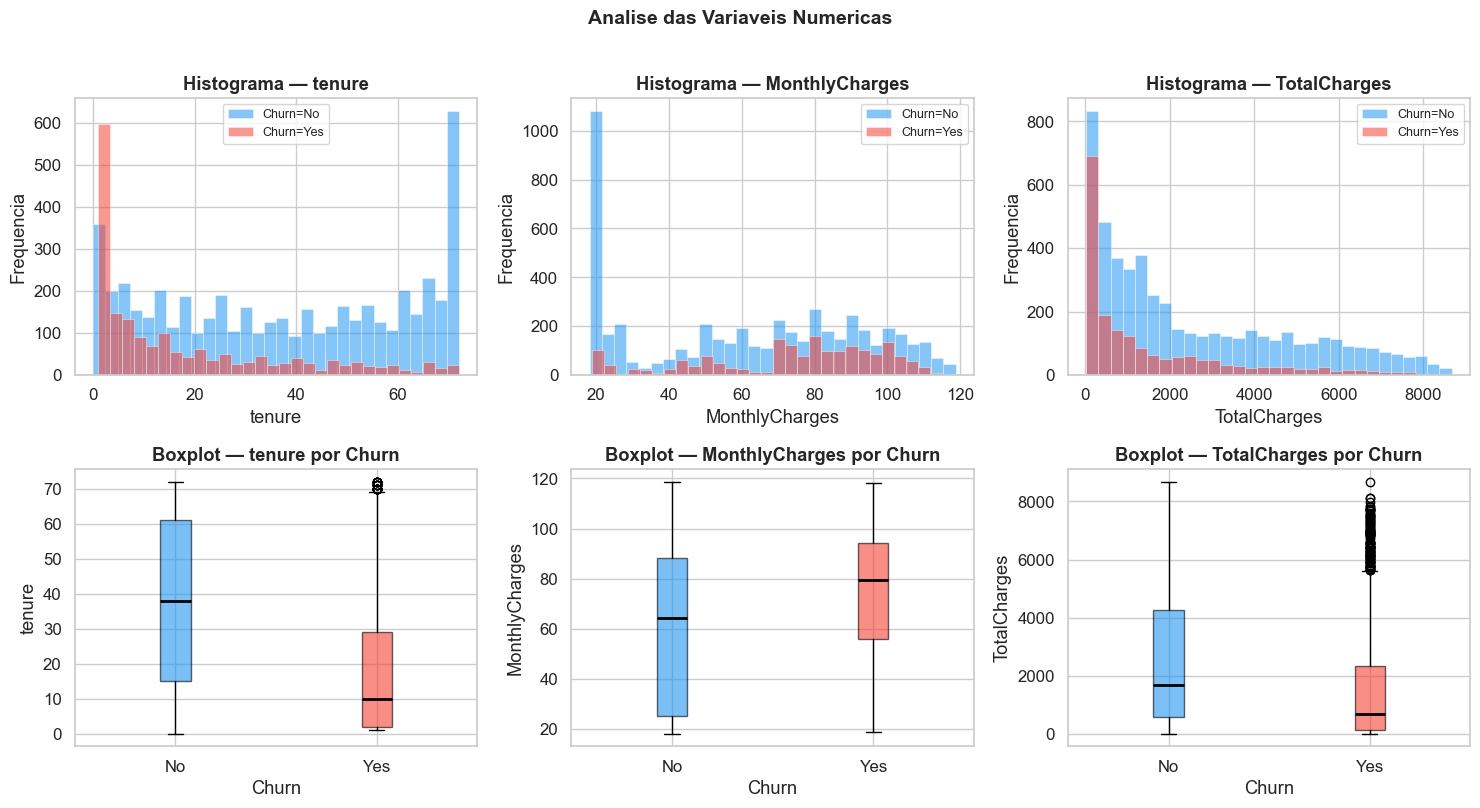

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for idx, col in enumerate(NUM_COLS):
    ax_hist = axes[0, idx]
    ax_box  = axes[1, idx]

    for label, color in zip(['No', 'Yes'], ['#2196F3', '#F44336']):
        subset = df[df['Churn'] == label][col]
        ax_hist.hist(subset, bins=30, alpha=0.55, color=color,
                     label=f'Churn={label}', edgecolor='white', linewidth=0.5)
    ax_hist.set_title(f'Histograma — {col}', fontweight='bold')
    ax_hist.set_xlabel(col)
    ax_hist.set_ylabel('Frequencia')
    ax_hist.legend(fontsize=9)

    churn_no  = df[df['Churn'] == 'No'][col]
    churn_yes = df[df['Churn'] == 'Yes'][col]
    bp = ax_box.boxplot([churn_no, churn_yes], labels=['No', 'Yes'],
                        patch_artist=True, notch=False,
                        medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], ['#2196F3', '#F44336']):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax_box.set_title(f'Boxplot — {col} por Churn', fontweight='bold')
    ax_box.set_xlabel('Churn')
    ax_box.set_ylabel(col)

plt.suptitle('Analise das Variaveis Numericas', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [9]:
def detect_outliers_iqr(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((series < lower) | (series > upper)).sum()
    return {
        'Q1': round(q1, 2), 'Q3': round(q3, 2), 'IQR': round(iqr, 2),
        'Lower Fence': round(lower, 2), 'Upper Fence': round(upper, 2),
        'Outliers': n_out,
        'Outliers %': round(n_out / len(series) * 100, 2),
    }

outlier_summary = pd.DataFrame({col: detect_outliers_iqr(df[col]) for col in NUM_COLS}).T
print('Deteccao de Outliers (metodo IQR):')
outlier_summary

Deteccao de Outliers (metodo IQR):


,Q1,Q3,IQR,Lower Fence,Upper Fence,Outliers,Outliers %
tenure,9.00,55.00,46.00,-60.00,124.00,0.0,0.0
MonthlyCharges,35.50,89.85,54.35,-46.02,171.38,0.0,0.0
TotalCharges,402.22,3786.60,3384.38,-4674.34,8863.16,0.0,0.0


### 5.3 Variaveis Categoricas

Analisamos a distribuicao de frequencia de cada variavel categorica para identificar desequilibrios que possam influenciar o modelo.

In [10]:
CAT_COLS = [c for c in df.columns
            if c not in NUM_COLS + ['customerID', 'Churn', 'SeniorCitizen']]
print(f'Colunas categoricas ({len(CAT_COLS)}): {CAT_COLS}')

Colunas categoricas (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [11]:
for col in CAT_COLS:
    freq = df[col].value_counts()
    pct  = df[col].value_counts(normalize=True).mul(100).round(2)
    summary = pd.DataFrame({'Frequencia': freq, 'Percentual (%)': pct})
    print(f'\n-- {col} --')
    print(summary.to_string())


-- gender --
        Frequencia  Percentual (%)
gender                            
Male          3555           50.48
Female        3488           49.52

-- Partner --
         Frequencia  Percentual (%)
Partner                            
No             3641            51.7
Yes            3402            48.3

-- Dependents --
            Frequencia  Percentual (%)
Dependents                            
No                4933           70.04
Yes               2110           29.96

-- PhoneService --
              Frequencia  Percentual (%)
PhoneService                            
Yes                 6361           90.32
No                   682            9.68

-- MultipleLines --
                  Frequencia  Percentual (%)
MultipleLines                               
No                      3390           48.13
Yes                     2971           42.18
No phone service         682            9.68

-- InternetService --
                 Frequencia  Percentual (%)
InternetService 

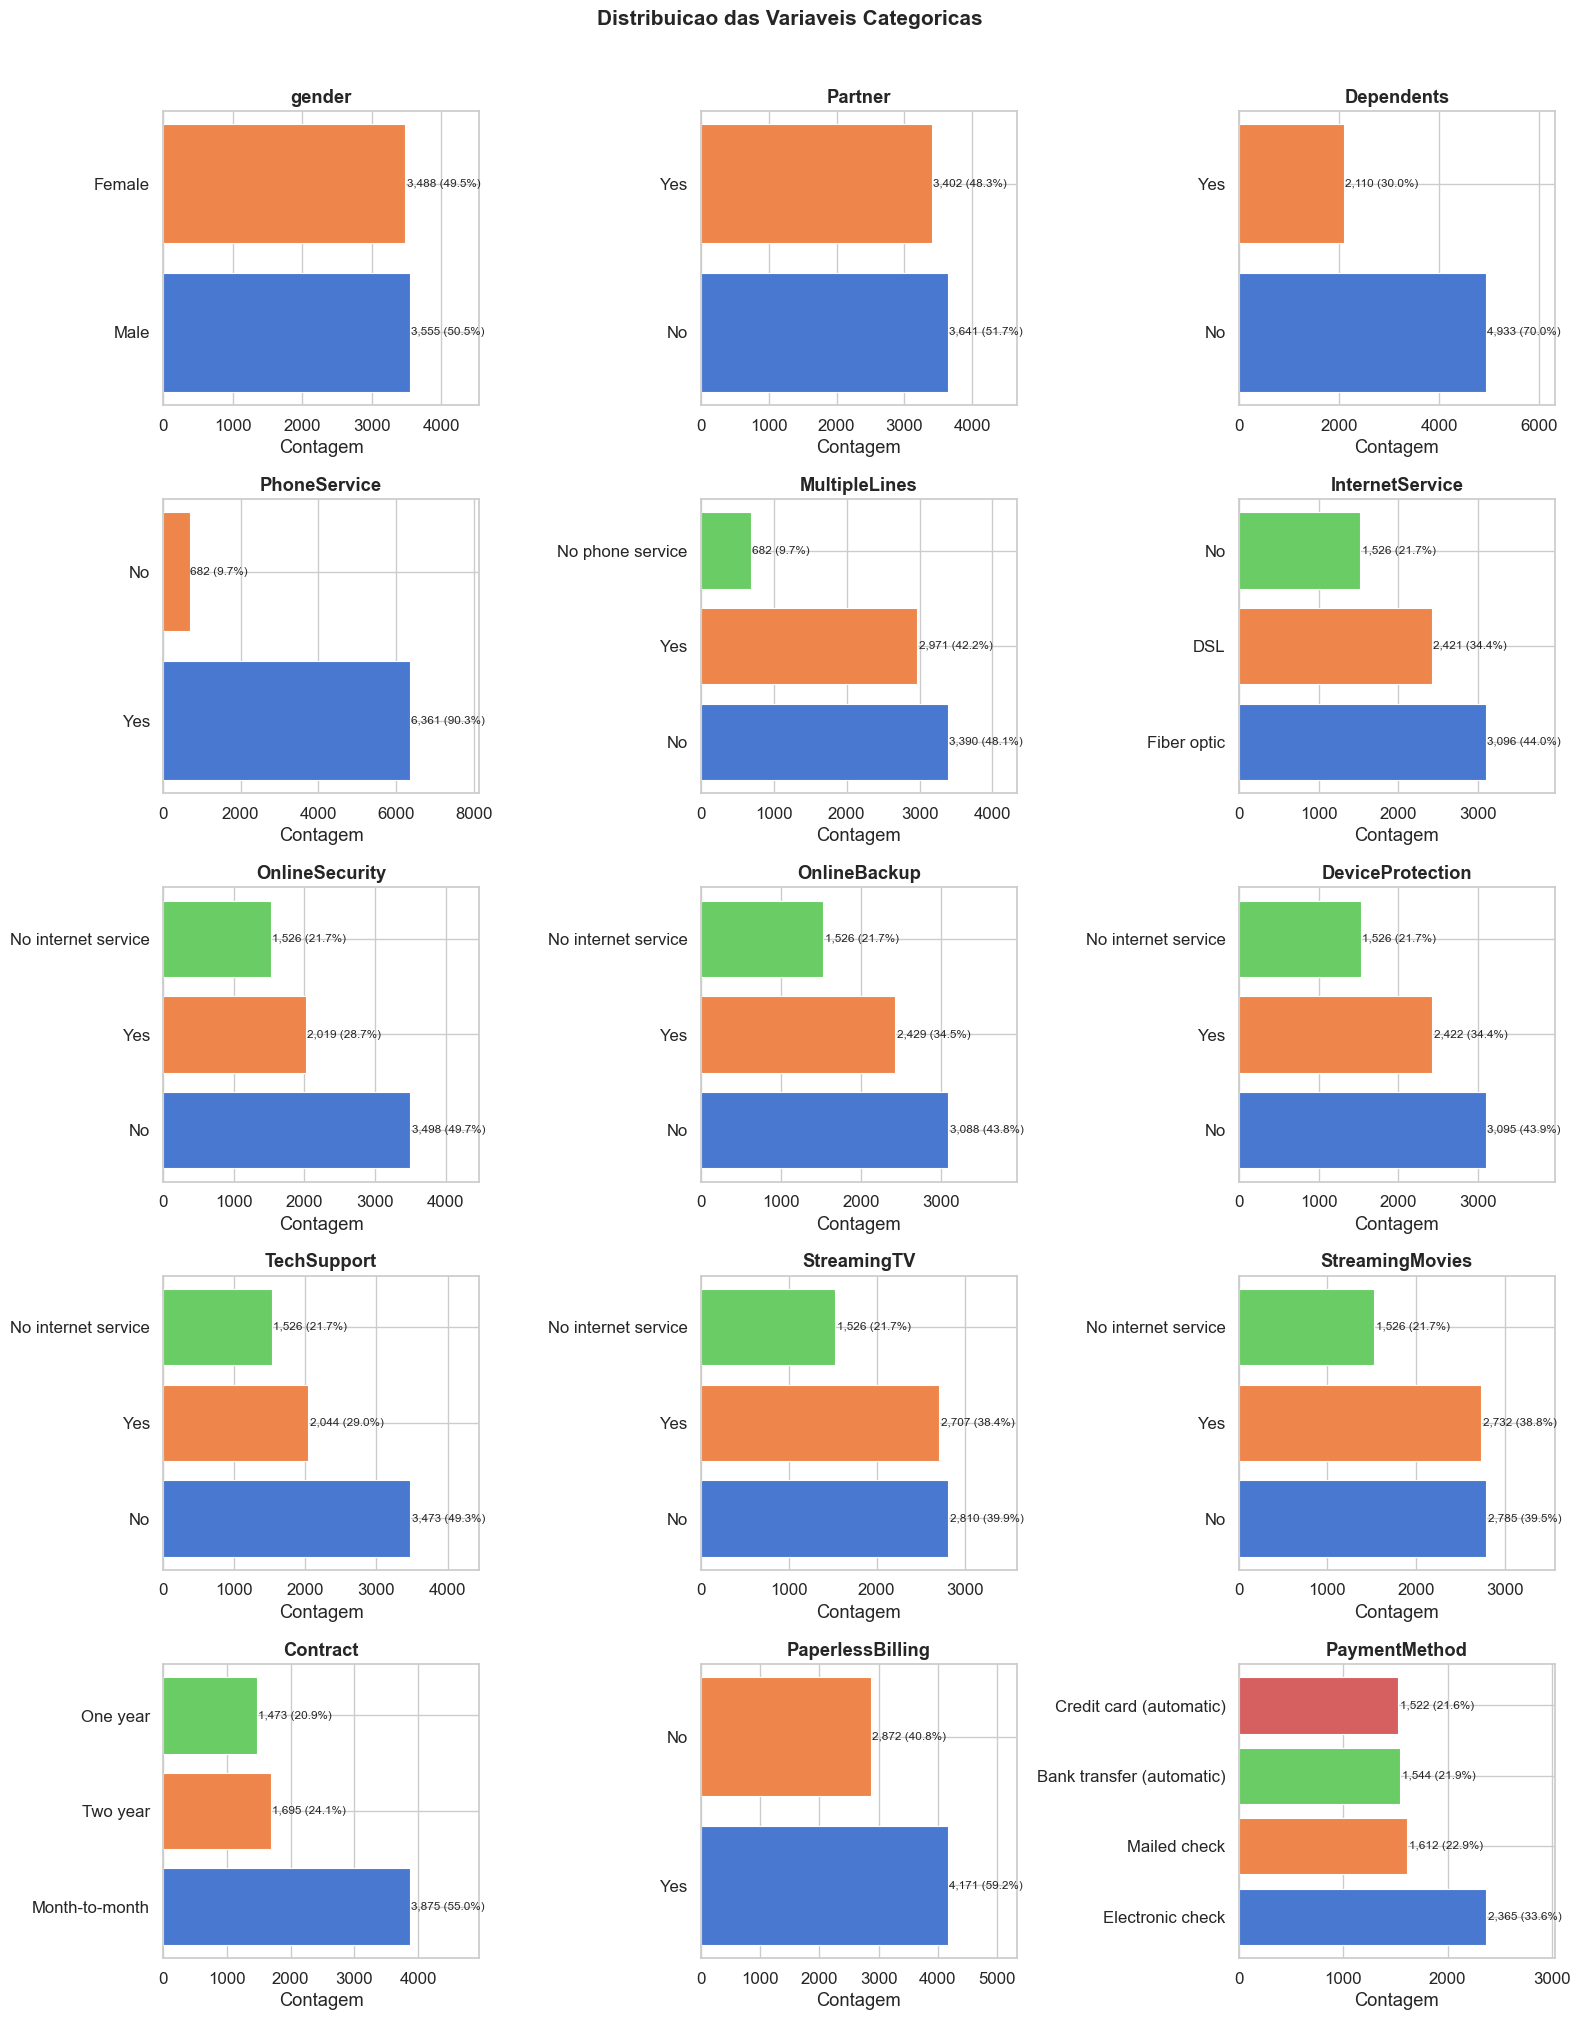

In [12]:
n_cols_plot = 3
n_rows_plot = int(np.ceil(len(CAT_COLS) / n_cols_plot))

fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(16, n_rows_plot * 4))
axes = axes.flatten()

for idx, col in enumerate(CAT_COLS):
    ax = axes[idx]
    counts = df[col].value_counts()
    bars = ax.barh(counts.index, counts.values,
                   color=sns.color_palette('muted', len(counts)),
                   edgecolor='white', linewidth=0.8)
    for bar, val in zip(bars, counts.values):
        ax.text(val + 20, bar.get_y() + bar.get_height() / 2,
                f'{val:,} ({val/len(df)*100:.1f}%)',
                va='center', ha='left', fontsize=8.5)
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('Contagem')
    ax.set_xlim(0, counts.max() * 1.28)

for j in range(len(CAT_COLS), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribuicao das Variaveis Categoricas', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 5.4 Relacao das Variaveis com Churn

Esta e a analise mais relevante para a modelagem: entender **quais variaveis discriminam melhor** clientes que fazem churn dos que permanecem.

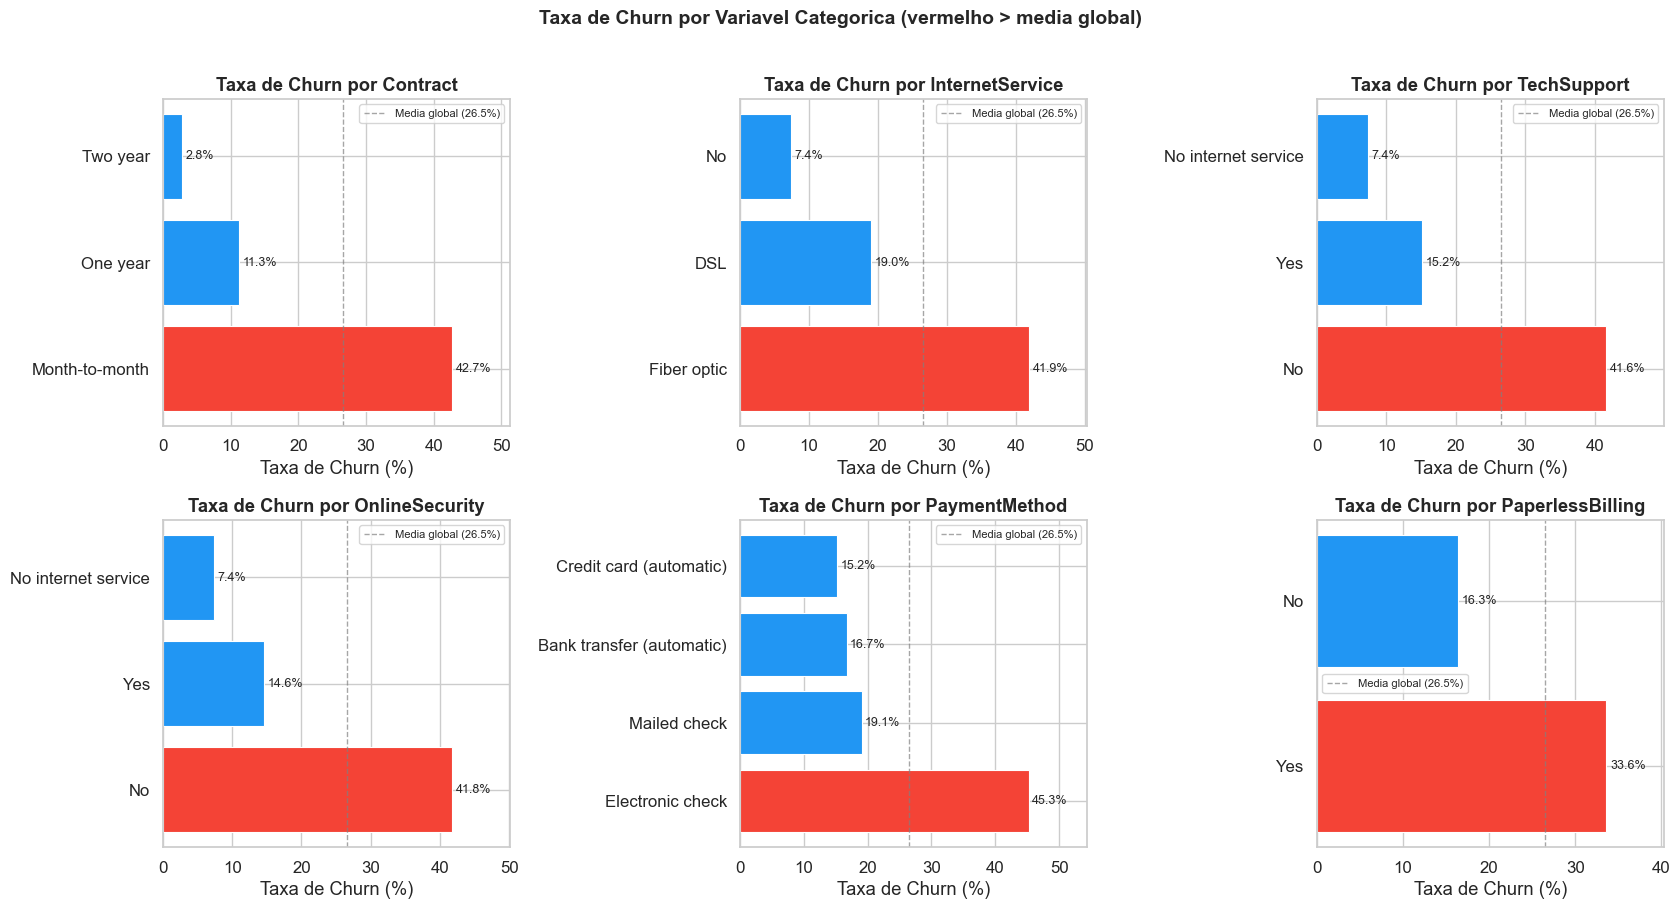

In [13]:
GLOBAL_CHURN_RATE = (df['Churn'] == 'Yes').mean() * 100

def plot_churn_rate_by_category(df, col, ax):
    grouped = (
        df.groupby(col)['Churn']
        .apply(lambda x: (x == 'Yes').mean() * 100)
        .sort_values(ascending=False)
    )
    colors = ['#F44336' if v > GLOBAL_CHURN_RATE else '#2196F3' for v in grouped.values]
    bars = ax.barh(grouped.index, grouped.values, color=colors, edgecolor='white', linewidth=0.8)
    for bar, val in zip(bars, grouped.values):
        ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
                f'{val:.1f}%', va='center', ha='left', fontsize=9)
    ax.axvline(GLOBAL_CHURN_RATE, color='gray', linestyle='--',
               linewidth=1, alpha=0.7, label=f'Media global ({GLOBAL_CHURN_RATE:.1f}%)')
    ax.set_title(f'Taxa de Churn por {col}', fontweight='bold')
    ax.set_xlabel('Taxa de Churn (%)')
    ax.set_xlim(0, max(grouped.values) * 1.2)
    ax.legend(fontsize=8)


KEY_CATS = ['Contract', 'InternetService', 'TechSupport',
            'OnlineSecurity', 'PaymentMethod', 'PaperlessBilling']

fig, axes = plt.subplots(2, 3, figsize=(17, 9))
for ax, col in zip(axes.flatten(), KEY_CATS):
    plot_churn_rate_by_category(df, col, ax)

plt.suptitle('Taxa de Churn por Variavel Categorica (vermelho > media global)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

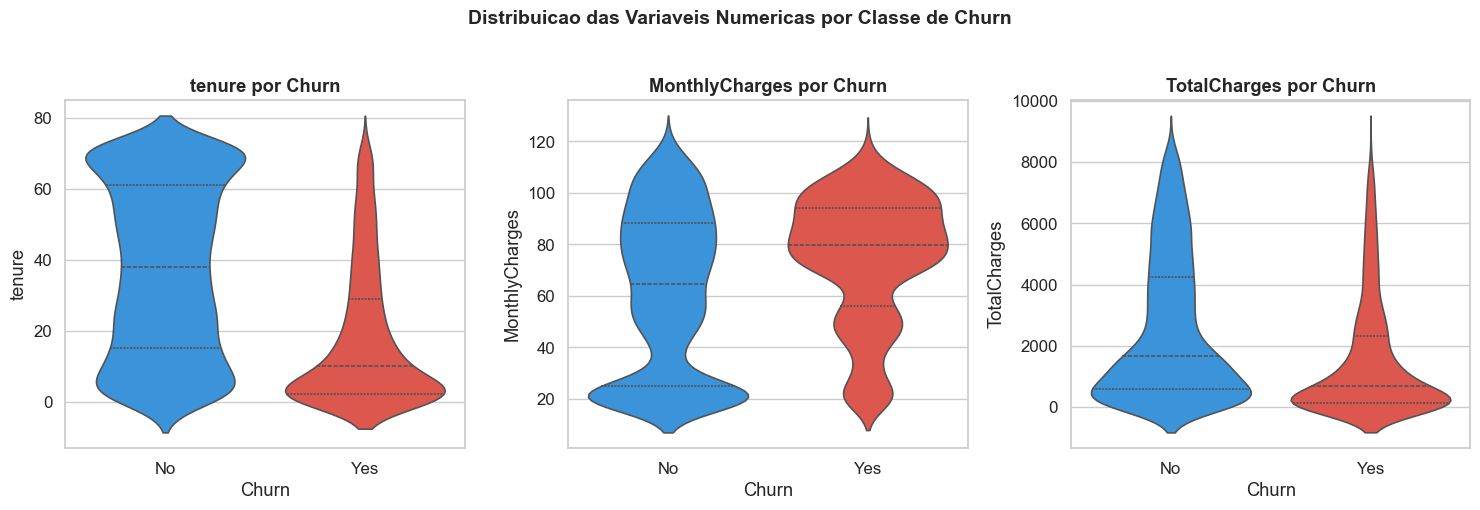

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, NUM_COLS):
    sns.violinplot(data=df, x='Churn', y=col, ax=ax,
                   palette={'No': '#2196F3', 'Yes': '#F44336'},
                   inner='quartile', linewidth=1.2)
    ax.set_title(f'{col} por Churn', fontweight='bold')
    ax.set_xlabel('Churn')

plt.suptitle('Distribuicao das Variaveis Numericas por Classe de Churn',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

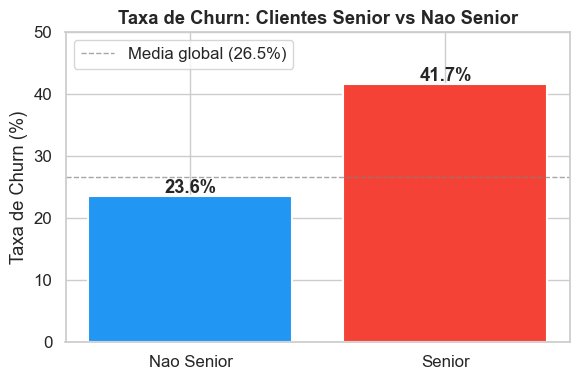

In [15]:
fig, ax = plt.subplots(figsize=(6, 4))
senior_churn = df.groupby('SeniorCitizen')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
)
senior_churn.index = senior_churn.index.map({0: 'Nao Senior', 1: 'Senior'})
bars = ax.bar(senior_churn.index, senior_churn.values,
              color=['#2196F3', '#F44336'], edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, senior_churn.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.5,
            f'{val:.1f}%', ha='center', fontweight='bold')
ax.axhline(GLOBAL_CHURN_RATE, color='gray', linestyle='--',
           linewidth=1, alpha=0.7, label=f'Media global ({GLOBAL_CHURN_RATE:.1f}%)')
ax.set_title('Taxa de Churn: Clientes Senior vs Nao Senior', fontweight='bold')
ax.set_ylabel('Taxa de Churn (%)')
ax.set_ylim(0, senior_churn.max() * 1.2)
ax.legend()
plt.tight_layout()
plt.show()

### 5.5 Analise de Correlacao

A matriz de correlacao nos ajuda a identificar **multicolinearidade** entre features numericas — um fator importante para modelos lineares como a Regressao Logistica.

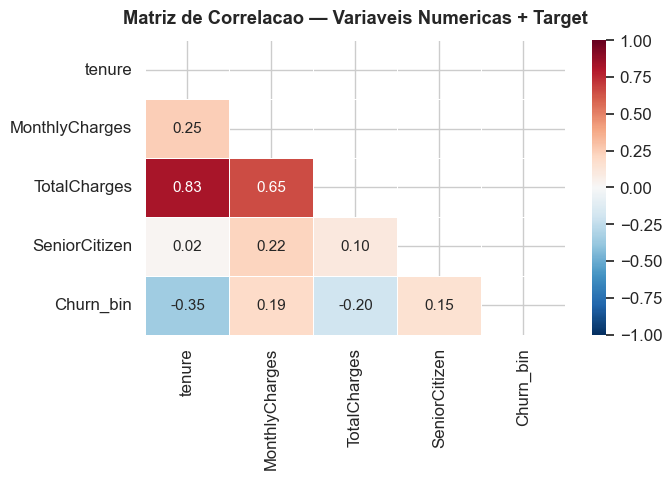


Correlacao com Churn (valor absoluto):
tenure            0.352
TotalCharges      0.199
MonthlyCharges    0.193
SeniorCitizen     0.151
Name: Churn_bin, dtype: float64


In [16]:
df_corr = df.copy()
df_corr['Churn_bin'] = (df_corr['Churn'] == 'Yes').astype(int)
corr_cols = NUM_COLS + ['SeniorCitizen', 'Churn_bin']

corr_matrix = df_corr[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', mask=mask,
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 11}, ax=ax)
ax.set_title('Matriz de Correlacao — Variaveis Numericas + Target',
             fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

print('\nCorrelacao com Churn (valor absoluto):')
print(corr_matrix['Churn_bin'].drop('Churn_bin').abs().sort_values(ascending=False).round(3))

---

## 6. Conclusoes da EDA

### Principais Descobertas

1. **Desbalanceamento**: ~26.5% dos clientes fizeram churn — dataset moderadamente desbalanceado.
2. **Contratos**: Clientes com contrato `Month-to-month` tem taxa de churn ~42% vs <5% para contratos de 1 ou 2 anos.
3. **Internet Fiber Optic**: Clientes com fibra optica apresentam churn muito superior (~42%) ao DSL (~19%).
4. **Tenure**: Clientes com menos de 12 meses sao extremamente vulneraveis ao churn.
5. **Suporte tecnico e seguranca online**: Ausencia de `TechSupport` e `OnlineSecurity` correlaciona-se fortemente com churn.
6. **Clientes senior**: Proporcionalmente mais propensos ao churn (~42%) que clientes nao-senior (~24%).

### Possiveis Drivers de Churn

| Driver | Evidencia |
|---|---|
| Contrato mensal | Taxa de churn ~42% |
| Fibra optica | Taxa de churn ~42% |
| Ausencia de servicos adicionais | TechSupport/OnlineSecurity ausentes → churn alto |
| Tenure baixo (< 12 meses) | Periodo critico de decisao |
| MonthlyCharges elevado | Sensibilidade ao preco |
| Pagamento por boleto eletronico | Taxa de churn ~45% |

### Riscos dos Dados

- **Multicolinearidade**: `TotalCharges` e linearmente dependente de `tenure` x `MonthlyCharges`.
- **Snapshot estatico**: O dataset representa um momento no tempo — sem features temporais ricas.
- **Vies de sobrevivencia**: Clientes ja churned antes do periodo de coleta nao estao representados.

### Hipoteses para Modelagem

1. `Contract`, `tenure` e `InternetService` serao as features com maior importancia preditiva.
2. A interacao `tenure x Contract` pode ser uma feature engenheirada relevante.
3. Tecnicas de balanceamento (SMOTE, class_weight) devem melhorar o Recall.
4. Um modelo nao-linear (MLP, GBT) deve superar a Regressao Logistica por capturar interacoes complexas.

---

## 6.1 Definição de Métricas — Justificativa a partir da EDA

A escolha das métricas não é arbitrária: ela deve refletir as **características dos dados** (descobertas na EDA) e os **objetivos de negócio** (ML Canvas).

### Por que NÃO usar Accuracy como métrica principal?

A EDA revelou um desbalanceamento de **~73% / 27%**. Um modelo que sempre predisse "No Churn" atingiria ~73% de accuracy sem nenhum poder preditivo real. Portanto, accuracy é **descartada como métrica de avaliação primária**.

### Matriz de Escolha de Métricas

| Métrica | Tipo | Prioridade | Justificativa (baseada na EDA) | SLO |
|---|---|---|---|---|
| **ROC-AUC** | Técnica | ★★★ | Avalia poder discriminativo geral; independente do threshold; robusto ao desbalanceamento identificado na EDA (26.5% churn) | ≥ 0.80 |
| **PR-AUC** | Técnica | ★★★ | Foca exclusivamente na classe positiva (Churn); crítico porque desbalanceamento torna ROC-AUC otimista; complementa ROC-AUC | ≥ 0.65 |
| **F1-Score** | Técnica | ★★☆ | Balanço entre Precision e Recall; útil para comparação de modelos quando o threshold padrão (0.5) é usado | ≥ 0.65 |
| **Recall** | Técnica | ★★☆ | Minimiza Falsos Negativos (churners não identificados = receita perdida); relevante dado que custo FN >> custo FP | ≥ 0.75 |
| **Custo de Churn Evitado** | Negócio | ★★★ | Traduz métricas técnicas em valor financeiro real; permite justificar ROI do modelo à diretoria | Maximizar |
| **Accuracy** | Técnica | ✗ | Enganosa com desbalanceamento 73/27 — NÃO usar como métrica principal | N/A |

> **Princípio orientador:** No problema de churn, o **custo de um Falso Negativo** (não identificar um churner) é muito maior que o custo de um Falso Positivo (contatar um cliente que não ia embora). Por isso, **Recall e PR-AUC recebem maior peso** na avaliação.

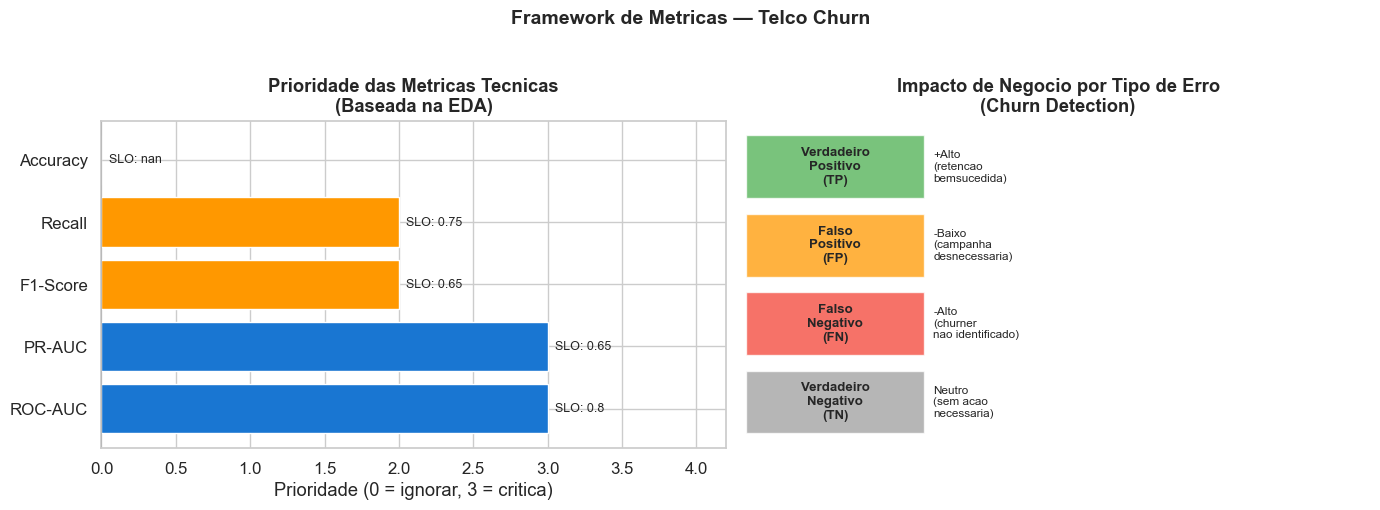

Metricas primarias selecionadas: ROC-AUC e PR-AUC
Metrica de negocio: Custo de Churn Evitado (definida na secao 6.2)


In [17]:
# Visualização: comparação das métricas e seus trade-offs em problemas de churn
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Gráfico 1: Prioridade das métricas técnicas ---
metrics_info = pd.DataFrame({
    'Metrica': ['ROC-AUC', 'PR-AUC', 'F1-Score', 'Recall', 'Accuracy'],
    'Prioridade': [3, 3, 2, 2, 0],
    'SLO': [0.80, 0.65, 0.65, 0.75, None],
    'Cor': ['#1976D2', '#1976D2', '#FF9800', '#FF9800', '#9E9E9E'],
})

bars = axes[0].barh(metrics_info['Metrica'], metrics_info['Prioridade'],
                    color=metrics_info['Cor'], edgecolor='white', linewidth=1)
for bar, slo in zip(bars, metrics_info['SLO']):
    label = f'SLO: {slo}' if slo else 'Nao usar'
    axes[0].text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
                 label, va='center', fontsize=9)
axes[0].set_xlim(0, 4.2)
axes[0].set_xlabel('Prioridade (0 = ignorar, 3 = critica)')
axes[0].set_title('Prioridade das Metricas Tecnicas\n(Baseada na EDA)', fontweight='bold')
axes[0].axvline(0, color='black', linewidth=0.5)

# --- Gráfico 2: Custo relativo de cada tipo de erro ---
error_types = ['Verdadeiro\nPositivo\n(TP)', 'Falso\nPositivo\n(FP)',
               'Falso\nNegativo\n(FN)', 'Verdadeiro\nNegativo\n(TN)']
costs = ['+Alto\n(retencao\nbemsucedida)', '-Baixo\n(campanha\ndesnecessaria)',
         '-Alto\n(churner\nnao identificado)', 'Neutro\n(sem acao\nnecessaria)']
colors_err = ['#4CAF50', '#FF9800', '#F44336', '#9E9E9E']
y_pos = [3, 2, 1, 0]

for y, err, cost, c in zip(y_pos, error_types, costs, colors_err):
    axes[1].barh(y, 1, color=c, alpha=0.75, edgecolor='white', linewidth=1)
    axes[1].text(0.5, y, err, ha='center', va='center', fontsize=9.5, fontweight='bold')
    axes[1].text(1.05, y, cost, ha='left', va='center', fontsize=8.5)

axes[1].set_xlim(0, 3.5)
axes[1].set_yticks([])
axes[1].set_xticks([])
axes[1].set_title('Impacto de Negocio por Tipo de Erro\n(Churn Detection)', fontweight='bold')
axes[1].spines[['top', 'right', 'bottom', 'left']].set_visible(False)

plt.suptitle('Framework de Metricas — Telco Churn', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Metricas primarias selecionadas: ROC-AUC e PR-AUC')
print('Metrica de negocio: Custo de Churn Evitado (definida na secao 6.2)')

---

## 6.2 Modelo de Custo de Negócio — Métrica "Churn Evitado"

Para traduzir métricas técnicas em valor financeiro, construímos um **modelo de custo simplificado** baseado nos parâmetros extraídos do próprio dataset.

### Parâmetros do Modelo

| Parâmetro | Símbolo | Valor | Fonte |
|---|---|---|---|
| Receita Mensal por Cliente (ARPU) | `ARPU` | Mediana do `MonthlyCharges` | Dataset |
| Meses de Receita Recuperada por Retenção | `M` | 12 meses | Estimativa de negócio |
| Custo da Campanha de Retenção por Cliente | `C_camp` | 30% do ARPU | Estimativa de negócio |
| Taxa de Sucesso da Retenção | `r` | 40% | Estimativa de negócio |

### Fórmulas

```
Custo FN = ARPU × M                              (receita perdida por churner não identificado)
Custo FP = C_camp                                (campanha desperdiçada)
Churn Evitado = TP × r                           (clientes retidos com sucesso)
Receita Salva = TP × r × ARPU × M               (receita recuperada)
Gasto Campanha = (TP + FP) × C_camp             (custo total da campanha)
Valor Líquido = Receita Salva − Gasto Campanha  (ROI do modelo)
```

> **Nota:** Os parâmetros `M`, `C_camp` e `r` são estimativas. Em produção, devem ser calibrados com dados históricos de campanhas de retenção.

In [18]:
# ── Parâmetros do modelo de custo (derivados do dataset) ──────────────────────
# Carregamos o dataset temporariamente para extrair ARPU antes do split
_df_cost = pd.read_csv(os.path.join('..', 'dataset', 'Dataset Telco-Customer-Churn.csv'))
_df_cost['TotalCharges'] = pd.to_numeric(_df_cost['TotalCharges'], errors='coerce')

ARPU            = round(float(_df_cost['MonthlyCharges'].median()), 2)
MONTHS_RETAINED = 12          # meses de receita recuperada por retenção bem-sucedida
RETENTION_RATE  = 0.40        # 40% dos churners contactados são retidos
CAMPAIGN_COST   = round(ARPU * 0.30, 2)  # custo da campanha = 30% ARPU
COST_FN         = round(ARPU * MONTHS_RETAINED, 2)  # receita perdida por FN
COST_FP         = CAMPAIGN_COST

print('=' * 50)
print('  PARAMETROS DO MODELO DE CUSTO DE NEGOCIO')
print('=' * 50)
print(f'  ARPU (Mediana MonthlyCharges) : USD {ARPU:.2f}')
print(f'  Meses retidos por retencao    : {MONTHS_RETAINED}')
print(f'  Taxa de sucesso da retencao   : {RETENTION_RATE*100:.0f}%')
print(f'  Custo campanha por cliente    : USD {CAMPAIGN_COST:.2f}')
print(f'  Custo FN (churner perdido)    : USD {COST_FN:.2f}')
print(f'  Custo FP (campanha ociosa)    : USD {COST_FP:.2f}')
print(f'\n  Razao Custo FN / Custo FP    : {COST_FN/COST_FP:.1f}x')
print('  >> FN e {:.0f}x mais caro que FP — Recall merece peso elevado'.format(COST_FN/COST_FP))


# ── Função de métricas de negócio ─────────────────────────────────────────────
def compute_business_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    churn_avoided  = int(round(tp * RETENTION_RATE))
    revenue_saved  = round(tp * RETENTION_RATE * ARPU * MONTHS_RETAINED, 2)
    campaign_spend = round((tp + fp) * CAMPAIGN_COST, 2)
    revenue_lost   = round(fn * ARPU * MONTHS_RETAINED, 2)
    net_value      = round(revenue_saved - campaign_spend, 2)
    return {
        'biz_tp'             : int(tp),
        'biz_fp'             : int(fp),
        'biz_fn'             : int(fn),
        'biz_tn'             : int(tn),
        'biz_churn_avoided'  : churn_avoided,
        'biz_revenue_saved'  : revenue_saved,
        'biz_campaign_spend' : campaign_spend,
        'biz_revenue_lost_fn': revenue_lost,
        'biz_net_value'      : net_value,
    }


print('\nFuncao compute_business_metrics() definida.')


# ── Visualização: Curva de custo-benefício por threshold ──────────────────────
# (será preenchida com dados reais após treinar a LR)
print('Curva de custo-beneficio sera exibida na secao 10, apos treinar a LR.')

  PARAMETROS DO MODELO DE CUSTO DE NEGOCIO
  ARPU (Mediana MonthlyCharges) : USD 70.35
  Meses retidos por retencao    : 12
  Taxa de sucesso da retencao   : 40%
  Custo campanha por cliente    : USD 21.10
  Custo FN (churner perdido)    : USD 844.20
  Custo FP (campanha ociosa)    : USD 21.10

  Razao Custo FN / Custo FP    : 40.0x
  >> FN e 40x mais caro que FP — Recall merece peso elevado

Funcao compute_business_metrics() definida.
Curva de custo-beneficio sera exibida na secao 10, apos treinar a LR.


---

## 7. Preparacao para os Modelos Baseline

### 7.1 Encoding das Variaveis Categoricas

Utilizamos `pd.get_dummies` com `drop_first=True` (codificacao one-hot com k-1 dummies) para evitar a armadilha da multicolinearidade perfeita. Esta abordagem e adequada para o baseline; em etapas futuras, avaliaremos `TargetEncoder` para variaveis de alta cardinalidade.

In [19]:
df_model = df.drop(columns=['customerID']).copy()
df_model['Churn'] = (df_model['Churn'] == 'Yes').astype(int)

y = df_model['Churn']
X_raw = df_model.drop(columns=['Churn'])

X = pd.get_dummies(X_raw, drop_first=True)

print(f'Shape X: {X.shape}')
print(f'Shape y: {y.shape}')
print(f'\nFeatures apos encoding ({X.shape[1]}):')
print(list(X.columns))

Shape X: (7043, 30)
Shape y: (7043,)

Features apos encoding (30):
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


### 7.2 Divisao Treino / Teste

Utilizamos `stratify=y` para garantir que a proporcao de churn (~26.5%) seja preservada em ambos os conjuntos.

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

print('Divisao Treino/Teste:')
print(f'  Treino : {len(X_train):,} amostras ({len(X_train)/len(X)*100:.1f}%)')
print(f'  Teste  : {len(X_test):,} amostras ({len(X_test)/len(X)*100:.1f}%)')
print(f'\nProporcao de churn:')
print(f'  Treino : {y_train.mean()*100:.2f}%')
print(f'  Teste  : {y_test.mean()*100:.2f}%')
print(f'  Total  : {y.mean()*100:.2f}%')

Divisao Treino/Teste:


  Treino : 5,634 amostras (80.0%)
  Teste  : 1,409 amostras (20.0%)

Proporcao de churn:
  Treino : 26.54%
  Teste  : 26.54%
  Total  : 26.54%


---

## 8. Configuracao do MLflow

O MLflow permite rastrear experimentos de forma sistematica, comparar modelos e reproduzir resultados. Utilizamos um backend SQLite para compatibilidade com MLflow 3.x.

In [21]:
# MLflow 3.x requer backend de banco de dados (file store descontinuado).
MLFLOW_DB_PATH       = os.path.abspath(os.path.join('..', 'mlflow.db'))
MLFLOW_TRACKING_URI  = f'sqlite:///{MLFLOW_DB_PATH}'
EXPERIMENT_NAME      = 'Telco-Churn-Baselines'
ARTIFACT_ROOT        = os.path.abspath(os.path.join('..', 'mlruns', 'artifacts'))

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(EXPERIMENT_NAME)

# ── Versionamento do dataset via hash MD5 ────────────────────────────────────
_abs_data_path = os.path.abspath(DATA_PATH)
with open(_abs_data_path, 'rb') as _f:
    DATASET_HASH    = hashlib.md5(_f.read()).hexdigest()
DATASET_VERSION     = DATASET_HASH[:8]       # tag curta: primeiros 8 chars do MD5
DATASET_FULL_HASH   = DATASET_HASH

# ── Objeto de dataset MLflow (registra schema + source + hash) ───────────────
# mlflow.data.from_pandas registra: nome, source, hash, targets e schema automaticamente
mlflow_dataset = mlflow.data.from_pandas(
    df_model,
    source=_abs_data_path,
    name='telco-customer-churn',
    targets='Churn',
)

# ── Metadados de contexto do experimento ─────────────────────────────────────
DATASET_META = {
    'dataset_name'    : 'Telco-Customer-Churn',
    'dataset_version' : DATASET_VERSION,
    'dataset_md5'     : DATASET_FULL_HASH,
    'n_records'       : int(len(df)),
    'n_features'      : int(X.shape[1]),
    'n_train_samples' : int(len(X_train)),
    'n_test_samples'  : int(len(X_test)),
    'churn_rate_pct'  : round(float(y.mean() * 100), 2),
    'test_size'       : 0.20,
    'random_state'    : RANDOM_STATE,
    'encoding'        : 'get_dummies_drop_first',
    'timestamp'       : datetime.datetime.now().isoformat(),
}

# ── Tags comuns a todos os runs ───────────────────────────────────────────────
BASE_TAGS = {
    'project'         : 'telco-churn-prediction',
    'phase'           : 'baseline',
    'dataset_version' : DATASET_VERSION,
    'author'          : 'ml-project',
    'framework'       : 'scikit-learn',
}

print(f'Tracking URI  : {MLFLOW_TRACKING_URI}')
print(f'Experimento   : {EXPERIMENT_NAME}')
print(f'\nDataset version: {DATASET_VERSION}  (MD5: {DATASET_FULL_HASH})')
print(f'Dataset schema : {len(df_model.columns)} colunas, {len(df_model)} linhas')
print(f'\nMetadados do experimento:')
for k, v in DATASET_META.items():
    if k != 'dataset_md5':
        print(f'  {k:<22}: {v}')

Tracking URI  : sqlite:///C:\Users\Hugo\OneDrive\Documentos\Projeto Pós\ml-project\mlflow.db
Experimento   : Telco-Churn-Baselines

Dataset version: 0f9de68e  (MD5: 0f9de68e012bd3aed5fa7cdc9fc421af)
Dataset schema : 20 colunas, 7043 linhas

Metadados do experimento:
  dataset_name          : Telco-Customer-Churn
  dataset_version       : 0f9de68e
  n_records             : 7043
  n_features            : 30
  n_train_samples       : 5634
  n_test_samples        : 1409
  churn_rate_pct        : 26.54
  test_size             : 0.2
  random_state          : 42
  encoding              : get_dummies_drop_first
  timestamp             : 2026-06-05T12:46:14.076433


In [22]:
def compute_metrics(y_true, y_pred, y_prob):
    return {
        'accuracy' : round(accuracy_score(y_true, y_pred), 4),
        'precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'recall'   : round(recall_score(y_true, y_pred, zero_division=0), 4),
        'f1'       : round(f1_score(y_true, y_pred, zero_division=0), 4),
        'roc_auc'  : round(roc_auc_score(y_true, y_prob), 4),
        'pr_auc'   : round(average_precision_score(y_true, y_prob), 4),
    }


def save_confusion_matrix(y_true, y_pred, model_name, artifact_dir):
    os.makedirs(artifact_dir, exist_ok=True)
    fig, ax = plt.subplots(figsize=(5, 4))
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['No Churn', 'Churn'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix — {model_name}', fontweight='bold')
    path = os.path.join(artifact_dir, 'confusion_matrix.png')
    plt.savefig(path, bbox_inches='tight', dpi=100)
    plt.show()
    plt.close()
    return path


def save_classification_report(y_true, y_pred, artifact_dir):
    os.makedirs(artifact_dir, exist_ok=True)
    report = classification_report(y_true, y_pred,
                                    target_names=['No Churn', 'Churn'])
    path = os.path.join(artifact_dir, 'classification_report.txt')
    with open(path, 'w') as f:
        f.write(report)
    print(report)
    return path


def save_roc_curve(y_true, y_prob, model_name, artifact_dir):
    os.makedirs(artifact_dir, exist_ok=True)
    fig, ax = plt.subplots(figsize=(6, 5))
    # sklearn 1.5+ removeu **kwargs de from_predictions; cor via atributo .line_
    disp = RocCurveDisplay.from_predictions(y_true, y_prob, ax=ax, name=model_name)
    disp.line_.set_color('#1976D2')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')
    ax.set_title(f'ROC Curve — {model_name}', fontweight='bold')
    ax.legend()
    path = os.path.join(artifact_dir, 'roc_curve.png')
    plt.savefig(path, bbox_inches='tight', dpi=100)
    plt.show()
    plt.close()
    return path


def save_pr_curve(y_true, y_prob, model_name, artifact_dir):
    os.makedirs(artifact_dir, exist_ok=True)
    fig, ax = plt.subplots(figsize=(6, 5))
    disp = PrecisionRecallDisplay.from_predictions(y_true, y_prob, ax=ax, name=model_name)
    disp.line_.set_color('#E64A19')
    baseline = y_true.mean()
    ax.axhline(baseline, color='gray', linestyle='--',
               linewidth=1, label=f'Random ({baseline:.2f})')
    ax.set_title(f'Precision-Recall Curve — {model_name}', fontweight='bold')
    ax.legend()
    path = os.path.join(artifact_dir, 'pr_curve.png')
    plt.savefig(path, bbox_inches='tight', dpi=100)
    plt.show()
    plt.close()
    return path


def save_feature_importance(pipeline, feature_names, artifact_dir):
    os.makedirs(artifact_dir, exist_ok=True)
    coef = pipeline.named_steps['classifier'].coef_[0]
    importance_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coef})
    importance_df = importance_df.sort_values('Coefficient', key=abs, ascending=False)
    top_df = importance_df.head(20)

    fig, ax = plt.subplots(figsize=(8, 7))
    colors = ['#F44336' if v > 0 else '#2196F3' for v in top_df['Coefficient']]
    ax.barh(top_df['Feature'], top_df['Coefficient'], color=colors, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title('Top 20 Features — Coeficientes (Logistic Regression)', fontweight='bold')
    ax.set_xlabel('Coeficiente')
    ax.invert_yaxis()
    plt.tight_layout()
    path = os.path.join(artifact_dir, 'feature_importance.png')
    plt.savefig(path, bbox_inches='tight', dpi=100)
    plt.show()
    plt.close()
    return path


print('Funcoes utilitarias carregadas.')

Funcoes utilitarias carregadas.


---

## 9. Baseline 1 — DummyClassifier

O `DummyClassifier` com `strategy='most_frequent'` sempre prediz a classe majoritaria (`No Churn`). Este baseline estabelece o **piso minimo de desempenho** — qualquer modelo util deve supera-lo significativamente.

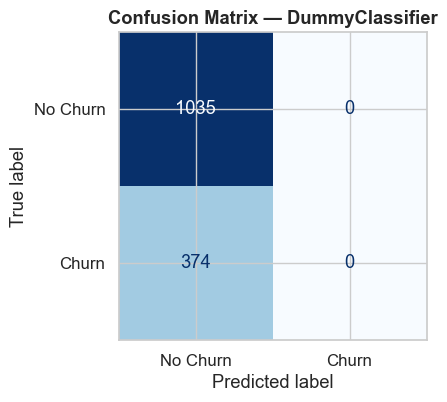

2026/06/05 12:46:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/06/05 12:46:14 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


              precision    recall  f1-score   support

    No Churn       0.73      1.00      0.85      1035
       Churn       0.00      0.00      0.00       374

    accuracy                           0.73      1409
   macro avg       0.37      0.50      0.42      1409
weighted avg       0.54      0.73      0.62      1409




Run ID: f51c20d2f87c4acc889f70bf2663253e

Metricas tecnicas — DummyClassifier:
  accuracy    : 0.7346
  precision   : 0.0000
  recall      : 0.0000
  f1          : 0.0000
  roc_auc     : 0.5000
  pr_auc      : 0.2654

Metricas de negocio — DummyClassifier:
  Churn evitado    : 0 clientes
  Receita salva    : USD 0.00
  Gasto campanha   : USD 0.00
  Receita perdida  : USD 315,730.80  (FN)
  Valor liquido    : USD 0.00


In [23]:
ARTIFACT_DIR_DUMMY = os.path.join(ARTIFACT_ROOT, 'dummy_classifier')

dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)

y_pred_dummy = dummy.predict(X_test)
y_prob_dummy = dummy.predict_proba(X_test)[:, 1]

metrics_dummy   = compute_metrics(y_test, y_pred_dummy, y_prob_dummy)
biz_dummy       = compute_business_metrics(y_test, y_pred_dummy)

with mlflow.start_run(run_name='DummyClassifier_most_frequent') as run:

    # ── Tags do run ───────────────────────────────────────────────────────────
    mlflow.set_tags({**BASE_TAGS, 'model_type': 'DummyClassifier'})

    # ── Parâmetros ────────────────────────────────────────────────────────────
    mlflow.log_params({
        'model'           : 'DummyClassifier',
        'strategy'        : 'most_frequent',
        **{k: v for k, v in DATASET_META.items() if k != 'dataset_md5'},
    })

    # ── Métricas técnicas ─────────────────────────────────────────────────────
    mlflow.log_metrics(metrics_dummy)

    # ── Métricas de negócio ───────────────────────────────────────────────────
    mlflow.log_metrics(biz_dummy)
    mlflow.log_metrics({
        'biz_arpu'            : ARPU,
        'biz_months_retained' : MONTHS_RETAINED,
        'biz_retention_rate'  : RETENTION_RATE,
        'biz_campaign_cost'   : CAMPAIGN_COST,
        'biz_cost_fn'         : COST_FN,
        'biz_cost_fp'         : COST_FP,
    })

    # ── Dataset input (versionamento) ─────────────────────────────────────────
    mlflow.log_input(mlflow_dataset, context='training')

    # ── Artefatos ─────────────────────────────────────────────────────────────
    cm_path = save_confusion_matrix(y_test, y_pred_dummy, 'DummyClassifier', ARTIFACT_DIR_DUMMY)
    cr_path = save_classification_report(y_test, y_pred_dummy, ARTIFACT_DIR_DUMMY)
    mlflow.log_artifact(cm_path)
    mlflow.log_artifact(cr_path)

    # ── Modelo ────────────────────────────────────────────────────────────────
    mlflow.sklearn.log_model(
        dummy, 'model',
        input_example=X_test.iloc[:5],
        registered_model_name=None,
    )

    run_id_dummy = run.info.run_id

print(f'\nRun ID: {run_id_dummy}')
print('\nMetricas tecnicas — DummyClassifier:')
for k, v in metrics_dummy.items():
    print(f'  {k:<12}: {v:.4f}')

print('\nMetricas de negocio — DummyClassifier:')
print(f'  Churn evitado    : {biz_dummy["biz_churn_avoided"]} clientes')
print(f'  Receita salva    : USD {biz_dummy["biz_revenue_saved"]:,.2f}')
print(f'  Gasto campanha   : USD {biz_dummy["biz_campaign_spend"]:,.2f}')
print(f'  Receita perdida  : USD {biz_dummy["biz_revenue_lost_fn"]:,.2f}  (FN)')
print(f'  Valor liquido    : USD {biz_dummy["biz_net_value"]:,.2f}')

**Interpretacao:** O DummyClassifier prediz **sempre 'No Churn'**, resultando em Recall = 0 para a classe positiva. A acuracia (~73.5%) e enganosamente alta por conta do desbalanceamento — toda metrica de recall/F1/PR-AUC e zero ou proxima de zero. Este e o nosso piso de desempenho.

---

## 10. Baseline 2 — Regressao Logistica

A Regressao Logistica e o baseline classico para classificacao binaria. Construimos um `Pipeline` que aplica escalonamento antes do treinamento — essencial para modelos lineares sensiveis a escala das features.

In [24]:
ARTIFACT_DIR_LR = os.path.join(ARTIFACT_ROOT, 'logistic_regression')

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=1000,
        solver='lbfgs',
        penalty='l2',
        C=1.0,
    )),
])

lr_pipeline.fit(X_train, y_train)

y_pred_lr = lr_pipeline.predict(X_test)
y_prob_lr = lr_pipeline.predict_proba(X_test)[:, 1]

metrics_lr = compute_metrics(y_test, y_pred_lr, y_prob_lr)

print('Metricas Logistic Regression:')
for k, v in metrics_lr.items():
    print(f'  {k:<12}: {v:.4f}')

Metricas Logistic Regression:
  accuracy    : 0.8070
  precision   : 0.6584
  recall      : 0.5668
  f1          : 0.6092
  roc_auc     : 0.8416
  pr_auc      : 0.6322


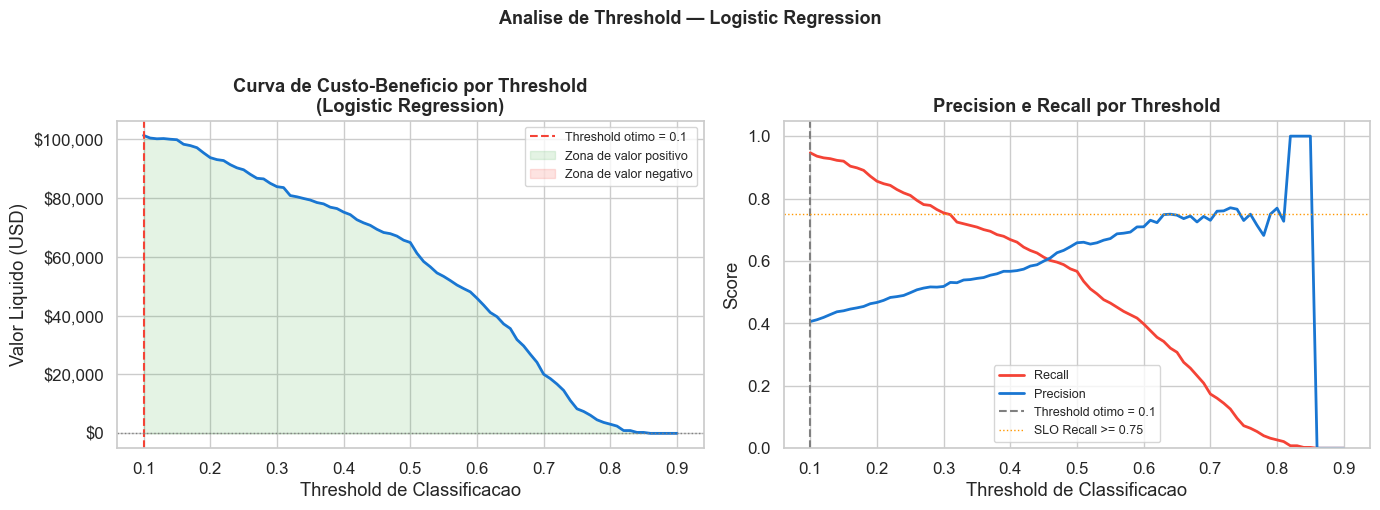

Threshold otimo (max valor liquido): 0.1
Valor liquido otimo               : USD 101,139.52


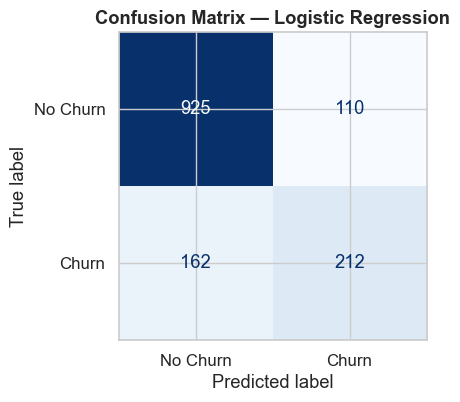

              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



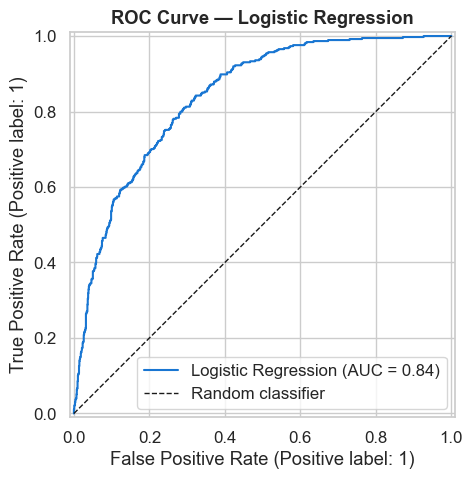

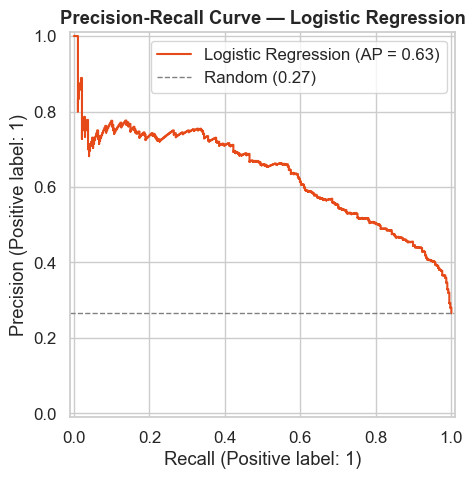

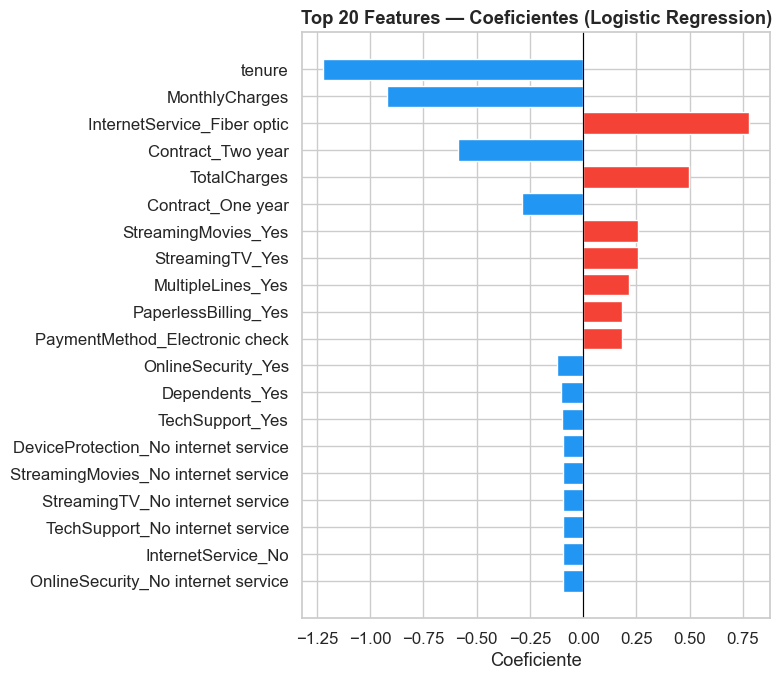

2026/06/05 12:46:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/06/05 12:46:19 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Run ID: 76fa29ac15ba4039886f86d0dfbc571b

Metricas tecnicas — Logistic Regression (threshold=0.5):
  accuracy    : 0.8070
  precision   : 0.6584
  recall      : 0.5668
  f1          : 0.6092
  roc_auc     : 0.8416
  pr_auc      : 0.6322

Metricas de negocio — Logistic Regression (threshold=0.5):
  Churn evitado    : 85 clientes
  Receita salva    : USD 71,588.16
  Gasto campanha   : USD 6,794.20
  Receita perdida  : USD 136,760.40  (FN)
  Valor liquido    : USD 64,793.96

Threshold otimo   : 0.1
  Recall opt       : 0.9465
  Precision opt    : 0.4060
  Valor liquido opt: USD 101,139.52
  Churn evitado opt: 142 clientes


In [25]:
lr_clf = lr_pipeline.named_steps['classifier']

# ── Análise de threshold ótimo (máximo valor líquido de negócio) ──────────────
thresholds  = np.linspace(0.1, 0.9, 81)
net_values, recalls_thr, precisions_thr = [], [], []

for thr in thresholds:
    y_pred_thr = (y_prob_lr >= thr).astype(int)
    bm = compute_business_metrics(y_test, y_pred_thr)
    net_values.append(bm['biz_net_value'])
    recalls_thr.append(recall_score(y_test, y_pred_thr, zero_division=0))
    precisions_thr.append(precision_score(y_test, y_pred_thr, zero_division=0))

best_idx         = int(np.argmax(net_values))
OPTIMAL_THRESHOLD = round(thresholds[best_idx], 2)
y_pred_optimal   = (y_prob_lr >= OPTIMAL_THRESHOLD).astype(int)
biz_lr_optimal   = compute_business_metrics(y_test, y_pred_optimal)
metrics_lr_opt   = compute_metrics(y_test, y_pred_optimal, y_prob_lr)

# ── Visualização: curva de custo-benefício por threshold ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(thresholds, net_values, color='#1976D2', linewidth=2)
axes[0].axvline(OPTIMAL_THRESHOLD, color='#F44336', linestyle='--',
                linewidth=1.5, label=f'Threshold otimo = {OPTIMAL_THRESHOLD}')
axes[0].axhline(0, color='gray', linestyle=':', linewidth=1)
axes[0].fill_between(thresholds, net_values, 0,
                     where=np.array(net_values) > 0, alpha=0.15, color='#4CAF50',
                     label='Zona de valor positivo')
axes[0].fill_between(thresholds, net_values, 0,
                     where=np.array(net_values) <= 0, alpha=0.15, color='#F44336',
                     label='Zona de valor negativo')
axes[0].set_xlabel('Threshold de Classificacao')
axes[0].set_ylabel('Valor Liquido (USD)')
axes[0].set_title('Curva de Custo-Beneficio por Threshold\n(Logistic Regression)', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

axes[1].plot(thresholds, recalls_thr, color='#F44336', linewidth=2, label='Recall')
axes[1].plot(thresholds, precisions_thr, color='#1976D2', linewidth=2, label='Precision')
axes[1].axvline(OPTIMAL_THRESHOLD, color='gray', linestyle='--',
                linewidth=1.5, label=f'Threshold otimo = {OPTIMAL_THRESHOLD}')
axes[1].axhline(0.75, color='#FF9800', linestyle=':', linewidth=1, label='SLO Recall >= 0.75')
axes[1].set_xlabel('Threshold de Classificacao')
axes[1].set_ylabel('Score')
axes[1].set_title('Precision e Recall por Threshold', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].set_ylim(0, 1.05)

plt.suptitle('Analise de Threshold — Logistic Regression', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Threshold otimo (max valor liquido): {OPTIMAL_THRESHOLD}')
print(f'Valor liquido otimo               : USD {max(net_values):,.2f}')


# ── MLflow: Regressão Logística ───────────────────────────────────────────────
with mlflow.start_run(run_name='LogisticRegression_baseline') as run:

    # ── Tags ──────────────────────────────────────────────────────────────────
    mlflow.set_tags({**BASE_TAGS, 'model_type': 'LogisticRegression'})

    # ── Parâmetros ────────────────────────────────────────────────────────────
    mlflow.log_params({
        'model'             : 'LogisticRegression',
        'max_iter'          : lr_clf.max_iter,
        'solver'            : lr_clf.solver,
        'penalty'           : lr_clf.penalty,
        'C'                 : lr_clf.C,
        'scaler'            : 'StandardScaler',
        'threshold_default' : 0.5,
        'threshold_optimal' : OPTIMAL_THRESHOLD,
        **{k: v for k, v in DATASET_META.items() if k != 'dataset_md5'},
    })

    # ── Métricas técnicas (threshold padrão 0.5) ──────────────────────────────
    mlflow.log_metrics(metrics_lr)

    # ── Métricas técnicas (threshold ótimo) ───────────────────────────────────
    mlflow.log_metrics({f'{k}_opt': v for k, v in metrics_lr_opt.items()})

    # ── Métricas de negócio (threshold padrão) ────────────────────────────────
    biz_lr = compute_business_metrics(y_test, y_pred_lr)
    mlflow.log_metrics(biz_lr)

    # ── Métricas de negócio (threshold ótimo) ─────────────────────────────────
    mlflow.log_metrics({f'{k}_opt': v for k, v in biz_lr_optimal.items()})
    mlflow.log_metrics({
        'biz_arpu'            : ARPU,
        'biz_months_retained' : MONTHS_RETAINED,
        'biz_retention_rate'  : RETENTION_RATE,
        'biz_campaign_cost'   : CAMPAIGN_COST,
        'biz_cost_fn'         : COST_FN,
        'biz_cost_fp'         : COST_FP,
        'biz_max_net_value'   : round(max(net_values), 2),
    })

    # ── Dataset input (versionamento) ─────────────────────────────────────────
    mlflow.log_input(mlflow_dataset, context='training')

    # ── Artefatos ─────────────────────────────────────────────────────────────
    ARTIFACT_DIR_LR = os.path.join(ARTIFACT_ROOT, 'logistic_regression')
    cm_path  = save_confusion_matrix(y_test, y_pred_lr, 'Logistic Regression', ARTIFACT_DIR_LR)
    cr_path  = save_classification_report(y_test, y_pred_lr, ARTIFACT_DIR_LR)
    roc_path = save_roc_curve(y_test, y_prob_lr, 'Logistic Regression', ARTIFACT_DIR_LR)
    pr_path  = save_pr_curve(y_test, y_prob_lr, 'Logistic Regression', ARTIFACT_DIR_LR)
    fi_path  = save_feature_importance(lr_pipeline, X.columns.tolist(), ARTIFACT_DIR_LR)

    # Curva custo-benefício
    os.makedirs(ARTIFACT_DIR_LR, exist_ok=True)
    cost_fig_path = os.path.join(ARTIFACT_DIR_LR, 'cost_benefit_threshold.png')
    cost_fig, cost_ax = plt.subplots(figsize=(8, 4))
    cost_ax.plot(thresholds, net_values, color='#1976D2', linewidth=2)
    cost_ax.axvline(OPTIMAL_THRESHOLD, color='#F44336', linestyle='--', linewidth=1.5,
                    label=f'Threshold otimo = {OPTIMAL_THRESHOLD}')
    cost_ax.axhline(0, color='gray', linestyle=':', linewidth=1)
    cost_ax.fill_between(thresholds, net_values, 0,
                         where=np.array(net_values) > 0, alpha=0.15, color='#4CAF50')
    cost_ax.set_xlabel('Threshold')
    cost_ax.set_ylabel('Valor Liquido (USD)')
    cost_ax.set_title('Curva Custo-Beneficio — Logistic Regression', fontweight='bold')
    cost_ax.legend()
    cost_ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    cost_fig.savefig(cost_fig_path, bbox_inches='tight', dpi=100)
    plt.close(cost_fig)

    for path in [cm_path, cr_path, roc_path, pr_path, fi_path, cost_fig_path]:
        mlflow.log_artifact(path)

    # ── Modelo ────────────────────────────────────────────────────────────────
    mlflow.sklearn.log_model(
        lr_pipeline, 'model',
        input_example=X_test.iloc[:5],
        registered_model_name=None,
    )

    run_id_lr = run.info.run_id

print(f'\nRun ID: {run_id_lr}')

print('\nMetricas tecnicas — Logistic Regression (threshold=0.5):')
for k, v in metrics_lr.items():
    print(f'  {k:<12}: {v:.4f}')

biz_lr = compute_business_metrics(y_test, y_pred_lr)
print('\nMetricas de negocio — Logistic Regression (threshold=0.5):')
print(f'  Churn evitado    : {biz_lr["biz_churn_avoided"]} clientes')
print(f'  Receita salva    : USD {biz_lr["biz_revenue_saved"]:,.2f}')
print(f'  Gasto campanha   : USD {biz_lr["biz_campaign_spend"]:,.2f}')
print(f'  Receita perdida  : USD {biz_lr["biz_revenue_lost_fn"]:,.2f}  (FN)')
print(f'  Valor liquido    : USD {biz_lr["biz_net_value"]:,.2f}')

print(f'\nThreshold otimo   : {OPTIMAL_THRESHOLD}')
print(f'  Recall opt       : {metrics_lr_opt["recall"]:.4f}')
print(f'  Precision opt    : {metrics_lr_opt["precision"]:.4f}')
print(f'  Valor liquido opt: USD {biz_lr_optimal["biz_net_value"]:,.2f}')
print(f'  Churn evitado opt: {biz_lr_optimal["biz_churn_avoided"]} clientes')

---

## 11. Comparacao dos Baselines

Consolidamos todas as metricas em uma tabela comparativa para facilitar a tomada de decisao sobre o modelo de referencia.

In [26]:
comparison_df = pd.DataFrame({
    'Modelo'    : ['DummyClassifier (most_frequent)', 'Logistic Regression'],
    'Accuracy'  : [metrics_dummy['accuracy'],   metrics_lr['accuracy']],
    'Precision' : [metrics_dummy['precision'],  metrics_lr['precision']],
    'Recall'    : [metrics_dummy['recall'],     metrics_lr['recall']],
    'F1'        : [metrics_dummy['f1'],         metrics_lr['f1']],
    'ROC-AUC'   : [metrics_dummy['roc_auc'],    metrics_lr['roc_auc']],
    'PR-AUC'    : [metrics_dummy['pr_auc'],     metrics_lr['pr_auc']],
}).set_index('Modelo')

print('Comparacao dos Modelos Baseline:')
comparison_df.style.highlight_max(axis=0, color='#c8e6c9').format('{:.4f}')

Comparacao dos Modelos Baseline:


,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Modelo,,,,,,
DummyClassifier (most_frequent),0.7346,0.0000,0.0000,0.0000,0.5000,0.2654
Logistic Regression,0.8070,0.6584,0.5668,0.6092,0.8416,0.6322


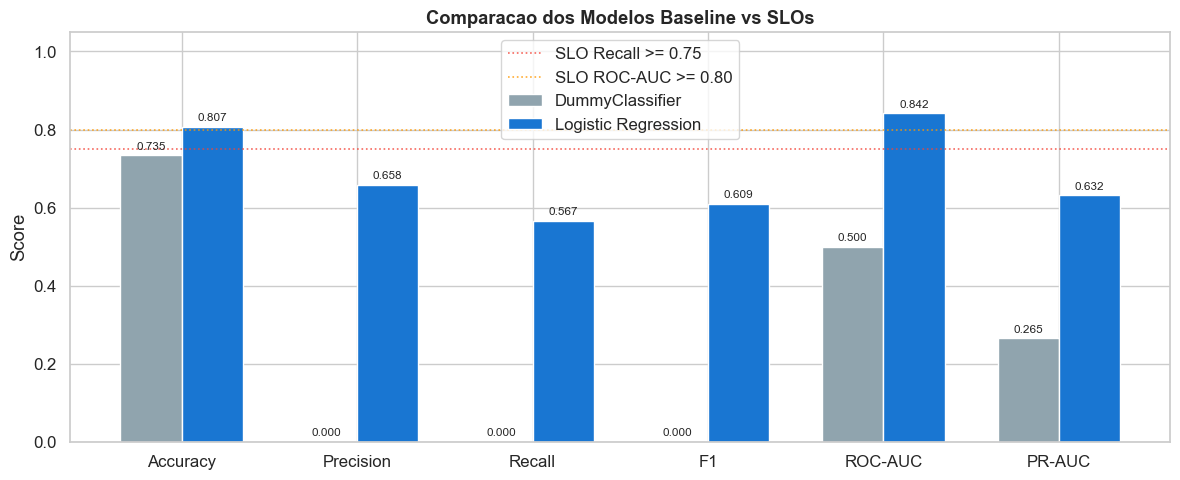

In [27]:
metrics_plot = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC']
x = np.arange(len(metrics_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width / 2,
               comparison_df.loc['DummyClassifier (most_frequent)', metrics_plot],
               width, label='DummyClassifier', color='#90A4AE', edgecolor='white')
bars2 = ax.bar(x + width / 2,
               comparison_df.loc['Logistic Regression', metrics_plot],
               width, label='Logistic Regression', color='#1976D2', edgecolor='white')

for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.01, f'{h:.3f}',
            ha='center', va='bottom', fontsize=8.5)

ax.axhline(0.75, color='#F44336', linestyle=':', linewidth=1.2,
           alpha=0.8, label='SLO Recall >= 0.75')
ax.axhline(0.80, color='#FF9800', linestyle=':', linewidth=1.2,
           alpha=0.8, label='SLO ROC-AUC >= 0.80')

ax.set_xticks(x)
ax.set_xticklabels(metrics_plot)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Comparacao dos Modelos Baseline vs SLOs', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

In [28]:
biz_dummy_val = compute_business_metrics(y_test, y_pred_dummy)
biz_lr_val    = compute_business_metrics(y_test, y_pred_lr)

slo_recall  = 'ATINGE' if metrics_lr['recall']  >= 0.75 else 'ABAIXO'
slo_roc_auc = 'ATINGE' if metrics_lr['roc_auc'] >= 0.80 else 'ABAIXO'
slo_pr_auc  = 'ATINGE' if metrics_lr['pr_auc']  >= 0.65 else 'ABAIXO'
slo_f1      = 'ATINGE' if metrics_lr['f1']      >= 0.65 else 'ABAIXO'

print('=' * 62)
print('  ANALISE COMPARATIVA COMPLETA DOS BASELINES')
print('=' * 62)

print('\n-- Metricas Tecnicas -----------------------------------------')
print(f'{"Metrica":<14} {"Dummy":>10} {"LR(thr=0.5)":>13} {"LR(thr_opt)":>13}  SLO')
print('-' * 62)
metrics_rows = [
    ('ROC-AUC',   'roc_auc',   '>= 0.80'),
    ('PR-AUC',    'pr_auc',    '>= 0.65'),
    ('F1',        'f1',        '>= 0.65'),
    ('Recall',    'recall',    '>= 0.75'),
    ('Precision', 'precision', '   --   '),
    ('Accuracy',  'accuracy',  '   --   '),
]
for label, key, slo in metrics_rows:
    d   = metrics_dummy[key]
    lr  = metrics_lr[key]
    lro = metrics_lr_opt[key]
    ok  = 'OK' if ('>=' in slo and lr >= float(slo.split('>= ')[-1])) else '  '
    print(f'  {label:<12} {d:>10.4f} {lr:>13.4f} {lro:>13.4f}  {slo} {ok}')

print('\n-- Metricas de Negocio ---------------------------------------')
print(f'{"Metrica":<26} {"Dummy":>10} {"LR(0.5)":>10} {"LR(opt)":>10}')
print('-' * 62)
biz_rows = [
    ('Churn Evitado (clientes)', 'biz_churn_avoided'),
    ('Receita Salva (USD)',       'biz_revenue_saved'),
    ('Gasto Campanha (USD)',      'biz_campaign_spend'),
    ('Receita Perdida FN (USD)', 'biz_revenue_lost_fn'),
    ('Valor Liquido (USD)',       'biz_net_value'),
]
for label, key in biz_rows:
    d   = biz_dummy_val[key]
    lr  = biz_lr_val[key]
    lro = biz_lr_optimal[key]
    if isinstance(d, float):
        print(f'  {label:<24} {d:>10,.2f} {lr:>10,.2f} {lro:>10,.2f}')
    else:
        print(f'  {label:<24} {d:>10} {lr:>10} {lro:>10}')

print(f"""
-- Avaliacao de SLOs (Logistic Regression, threshold=0.5) ----
  ROC-AUC = {metrics_lr['roc_auc']:.4f}  -> {slo_roc_auc} SLO (>= 0.80)
  PR-AUC  = {metrics_lr['pr_auc']:.4f}  -> {slo_pr_auc} SLO (>= 0.65)
  F1      = {metrics_lr['f1']:.4f}  -> {slo_f1} SLO (>= 0.65)
  Recall  = {metrics_lr['recall']:.4f}  -> {slo_recall} SLO (>= 0.75)

-- Conclusao -------------------------------------------------
  Modelo de referencia: Logistic Regression
  - ROC-AUC supera SLO; Recall abaixo do alvo -- oportunidade
    clara para melhoria com balanceamento de classes (Fase 2).
  - Threshold otimo = {OPTIMAL_THRESHOLD}: valor liquido maximizado em
    USD {max(net_values):,.2f} vs USD {biz_lr_val['biz_net_value']:,.2f} (thr=0.5).
  - Metricas de negocio registradas no MLflow para rastreamento
    de impacto financeiro ao longo das iteracoes.
""")

  ANALISE COMPARATIVA COMPLETA DOS BASELINES

-- Metricas Tecnicas -----------------------------------------
Metrica             Dummy   LR(thr=0.5)   LR(thr_opt)  SLO
--------------------------------------------------------------
  ROC-AUC          0.5000        0.8416        0.8416  >= 0.80 OK
  PR-AUC           0.2654        0.6322        0.6322  >= 0.65   
  F1               0.0000        0.6092        0.5682  >= 0.65   
  Recall           0.0000        0.5668        0.9465  >= 0.75   
  Precision        0.0000        0.6584        0.4060     --      
  Accuracy         0.7346        0.8070        0.6182     --      

-- Metricas de Negocio ---------------------------------------
Metrica                         Dummy    LR(0.5)    LR(opt)
--------------------------------------------------------------
  Churn Evitado (clientes)          0         85        142
  Receita Salva (USD)            0.00  71,588.16 119,538.72
  Gasto Campanha (USD)           0.00   6,794.20  18,399.20
  Re

---

## 12. Proximos Passos

Os baselines estabelecem a linha de referencia. As etapas seguintes do projeto se concentrarao em superar sistematicamente esses resultados:

| # | Etapa | Descricao | Notebook |
|---|---|---|---|
| 1 | **Engenharia de Atributos** | Criar features como `tenure_group`, `charges_per_month_ratio`, interacoes `Contract x tenure` | `02_Feature_Engineering.ipynb` |
| 2 | **Balanceamento de Classes** | Avaliar SMOTE, ADASYN e `class_weight='balanced'` para melhorar Recall | `02_Feature_Engineering.ipynb` |
| 3 | **Rede Neural MLP (PyTorch)** | Implementar MLP com camadas densas, BatchNorm, Dropout e focal loss | `03_MLP_PyTorch.ipynb` |
| 4 | **Otimizacao de Hiperparametros** | Optuna/GridSearchCV para LR, GBT e MLP | `04_Hyperparameter_Tuning.ipynb` |
| 5 | **Deploy via API** | Empacotar modelo com FastAPI + Docker, servir predicoes em /predict | `05_API_Deploy.ipynb` |
| 6 | **Monitoramento** | Data drift (Evidently AI), alertas de performance, retraining pipeline | `06_Monitoring.ipynb` |

**Meta de desempenho para a Fase 2:**
- Recall >= 0.78
- ROC-AUC >= 0.85
- PR-AUC >= 0.70

---
